In [16]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from sigfig import round

In [17]:
ch1_attenuations = np.array([3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20], dtype=np.float64)
ch2_attenuations = ch1_attenuations - 0.5
resolutions =   np.array([7.02, 7.03, 7.26, 7.22, 7.57, 8.43, 8.51, 8.89 , 9.84, 10.63, 11.41, 12.6, 13.5, 15.2, 16.3, 18.1, 20.5, 22.2])
uncertainties = np.array([0.06, 0.06, 0.06, 0.06,  0.06, 0.07, 0.07, 0.07, 0.08, 0.09, 0.09, 0.1, 0.1, 0.1, 0.1, 0.2, 0.2, 0.2])

In [18]:
FS = 2 # FS for ch2
dBFS = FS - ch2_attenuations
sort_dBFS = dBFS.argsort()
dBFS = dBFS[sort_dBFS]
resolutions = resolutions[sort_dBFS]
uncertainties = uncertainties[sort_dBFS]

In [19]:
def res_fit(power_dB, A, B):
    return A*10**(-power_dB/20) + B

In [23]:
A0 = resolutions[0] * 10**(dBFS[0]/20)
B0 = resolutions[-1]
p0 = [A0, B0]

popt, pcov = curve_fit(res_fit, dBFS, resolutions, p0=p0, sigma=uncertainties, absolute_sigma=True)
perr = np.sqrt(np.diag(pcov))
print(f'A: {round(popt[0], perr[0])}')
print(f'B: {round(popt[1], perr[1])}')

resid = (resolutions - res_fit(dBFS, *popt)) / uncertainties
ndf = len(resolutions) - 2
chi2_red = float(np.sum(resid ** 2) / ndf)
print(f'Red. chi2: {chi2_red}')


A: 2.30 ± 0.01
B: 3.98 ± 0.04
Red. chi2: 22.577235592000616


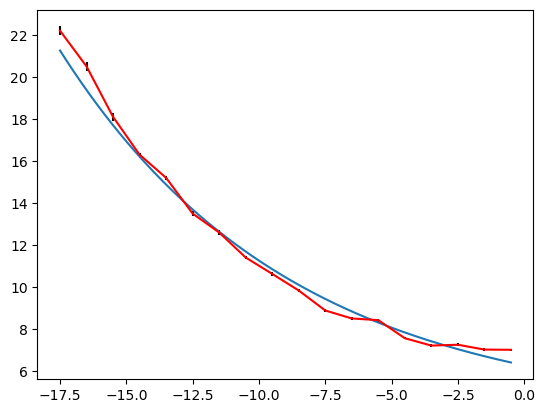

In [21]:
fig, ax = plt.subplots()
ax.errorbar(dBFS, resolutions, yerr=uncertainties, color='red', ecolor='black')
fit_domain = np.linspace(dBFS[0], dBFS[-1], 300)
ax.plot(fit_domain, res_fit(fit_domain, *popt))
plt.show()